# Deep Learning

Syaqila Najwa Amalia Hambali - 2802488481

Miryam Almira Levina - 2802465944

Link Gdrive kami: https://drive.google.com/drive/folders/111mm5ANr-tI24D0CA8GdVVW75m17tsBL?usp=drive_link

Link Video: https://drive.google.com/drive/folders/111mm5ANr-tI24D0CA8GdVVW75m17tsBL

# EDA

**Inshight:**

Ada 3 hal yang dicek: berapa banyak gambar tiap kelas, seberapa bervariasi ukuran gambarnya, dan apakah tiap kelas punya warna yang khas


kila

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Activation, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score, accuracy_score
from google.colab import drive

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Ganti lokasi ini sesuai dengan folder dataset di dalam Drive
DATA_DIR = '/content/drive/MyDrive/PROJECT_DL/data'

# Pastikan folder terbaca
kelas_bencana = sorted(os.listdir(DATA_DIR))

Mounted at /content/drive


kila

In [ ]:
SEED = 115

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

kila

In [ ]:
#config
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.2

#set seed biar output / hasilnya ga berubah tiap kli di run
def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    os.environ['TF_DETERMINISTIC_OPS'] = '1'


print(f"Kelas: {kelas_bencana}")

jumlah_data = {}
for kelas in kelas_bencana:
    folder = os.path.join(DATA_DIR, kelas)
    jumlah = len([f for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    jumlah_data[kelas] = jumlah
    print(f"  {kelas:<20} : {jumlah} gambar")

print(f"\n  Total : {sum(jumlah_data.values())} gambar")

Kelas: ['Earthquake', 'Land_Slide', 'Urban_Fire', 'Water_Disaster']
  Earthquake           : 435 gambar
  Land_Slide           : 456 gambar
  Urban_Fire           : 419 gambar
  Water_Disaster       : 1035 gambar

  Total : 2345 gambar


Visualisasi data per kelas

kila

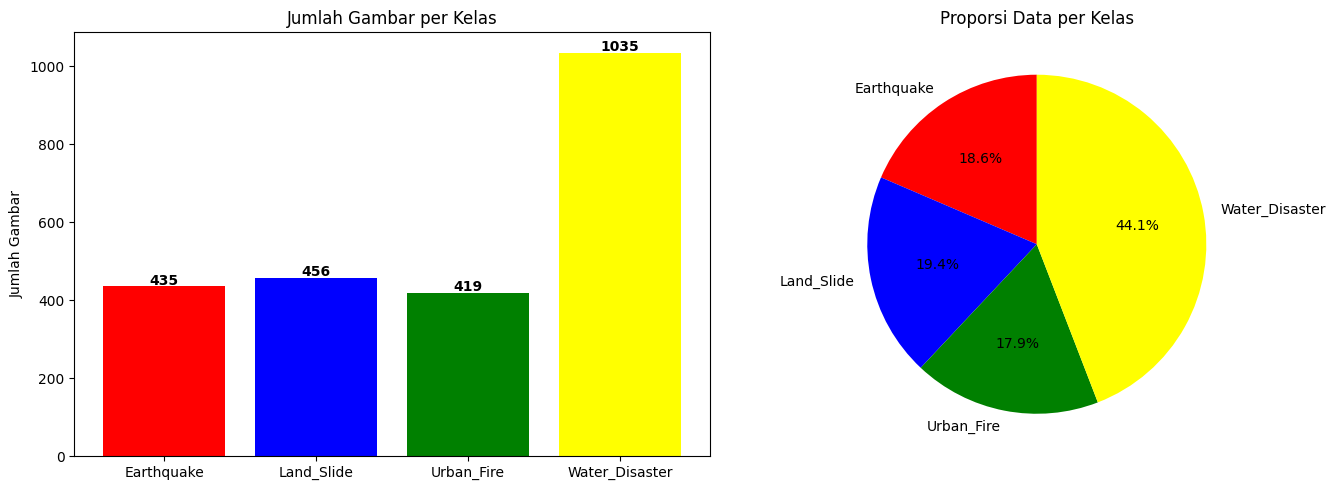

Total data: 2345 
Kelas dengan data terbanyak: Water_Disaster (1035) 
Kelas dengan tugas terdikit: Urban_Fire (419)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
warna = ['red', 'blue', 'green', 'yellow']

bars = axes[0].bar(jumlah_data.keys(), jumlah_data.values(), color=warna)
for bar, nilai in zip(bars, jumlah_data.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(nilai), ha='center', fontweight='bold')
axes[0].set_title('Jumlah Gambar per Kelas')
axes[0].set_ylabel('Jumlah Gambar')

axes[1].pie(jumlah_data.values(), labels=jumlah_data.keys(),
            autopct='%1.1f%%', colors=warna, startangle=90)
axes[1].set_title('Proporsi Data per Kelas')

plt.tight_layout()
plt.show()

total = sum(jumlah_data.values())
max_k = max(jumlah_data, key=jumlah_data.get)
min_k = min(jumlah_data, key=jumlah_data.get)
print(f"Total data: {total} \nKelas dengan data terbanyak: {max_k} ({jumlah_data[max_k]}) \nKelas dengan data terdikit: {min_k} ({jumlah_data[min_k]})")

**Inshigt:** Water_Disaster jauh lebih banyak dari kelas lain, 1.035 dari total 2.345 gambar alias 44%. Ini masalah karena kalau dibiarkan, model bakal lebih sering nebak "Water_Disaster" karena datanya paling dominan. Makanya nanti kita butuh class weighting.

kila

/tmp/ipykernel_1273/2746268423.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([lebar_gambar[k] for k in kelas_bencana], labels=kelas_bencana, patch_artist=True)


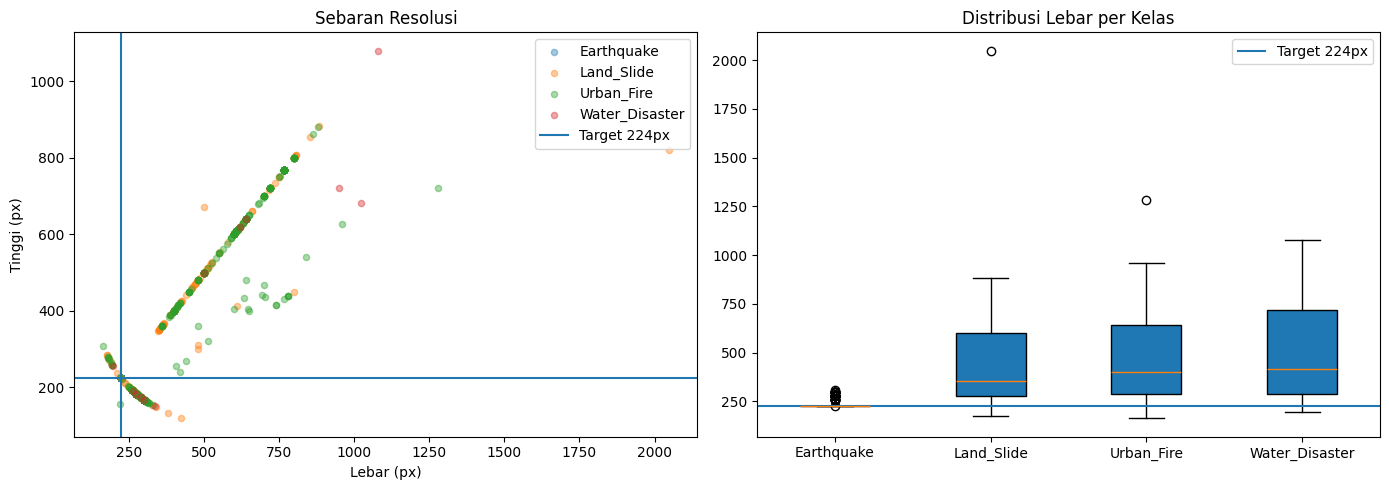



Kelas                   Min W    Max W    Avg W    Min H    Max H    Avg H
Earthquake                224      308      228      164      225      220
Land_Slide                177     2048      432      119      882      383
Urban_Fire                163     1280      461      153      880      402
Water_Disaster            198     1080      539      150     1080      446


In [ ]:
lebar_gambar  = {k: [] for k in kelas_bencana}
tinggi_gambar = {k: [] for k in kelas_bencana}

for kelas in kelas_bencana:
    folder = os.path.join(DATA_DIR, kelas)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            try:
                img = Image.open(os.path.join(folder, fname))
                w, h = img.size
                lebar_gambar[kelas].append(w)
                tinggi_gambar[kelas].append(h)
            except:
                pass

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for kelas in kelas_bencana:
    axes[0].scatter(lebar_gambar[kelas], tinggi_gambar[kelas], label=kelas, alpha=0.4, s=20)
axes[0].axvline(x=224, label='Target 224px')
axes[0].axhline(y=224)
axes[0].set_title('Sebaran Resolusi')
axes[0].set_xlabel('Lebar (px)')
axes[0].set_ylabel('Tinggi (px)')
axes[0].legend()

axes[1].boxplot([lebar_gambar[k] for k in kelas_bencana], labels=kelas_bencana, patch_artist=True)
axes[1].axhline(y=224, label='Target 224px')
axes[1].set_title('Distribusi Lebar per Kelas')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n")
print(f"{'Kelas':<20} {'Min W':>8} {'Max W':>8} {'Avg W':>8} {'Min H':>8} {'Max H':>8} {'Avg H':>8}")

for kelas in kelas_bencana:
    lw, th = lebar_gambar[kelas], tinggi_gambar[kelas]
    print(f"{kelas:<20} {min(lw):>8} {max(lw):>8} {int(np.mean(lw)):>8} {min(th):>8} {max(th):>8} {int(np.mean(th)):>8}")

Sebaran resolusi:

Earthquake ukurannya paling seragam dan udah deket ke target 224px. Tiga kelas lainnya jauh lebih bervariasi, Land_Slide bahkan ada yang sampai 2048px lebarnya. Ini kenapa resize ke 224x224 wajib dilakukan, bukan opsional.

Distribusi Lebar per kelas:

Boxplot ini mastiin kalau Earthquake emang paling konsisten, sedangkan Water_Disaster punya outlier paling banyak. Kesimpulannya: tanpa resize, layer Conv2D nggak bisa nerima input dengan dimensi yang beda-beda.

mimi

In [ ]:
N_SAMPLE = 100
mean_rgb = {}

for kelas in kelas_bencana:
    lokasi_folder = os.path.join(DATA_DIR, kelas)
    list_gambar = [f for f in os.listdir(lokasi_folder)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = random.sample(list_gambar, min(N_SAMPLE, len(list_gambar)))

    all_r, all_g, all_b = [], [], []
    for nama_file in sample:
        try:
            arr = np.array(Image.open(os.path.join(lokasi_folder, nama_file)).convert('RGB').resize((224, 224)), dtype=np.float32)
            all_r.append(arr[:,:,0].mean())
            all_g.append(arr[:,:,1].mean())
            all_b.append(arr[:,:,2].mean())
        except:
            pass

    mean_rgb[kelas] = {'R': np.mean(all_r), 'G': np.mean(all_g), 'B': np.mean(all_b)}
    print(f"{kelas}: R={mean_rgb[kelas]['R']:.1f} G={mean_rgb[kelas]['G']:.1f} B={mean_rgb[kelas]['B']:.1f}")

Earthquake: R=114.8 G=110.6 B=107.9
Land_Slide: R=116.1 G=114.3 B=105.3
Urban_Fire: R=110.3 G=93.3 B=83.9
Water_Disaster: R=125.0 G=126.0 B=119.9


Urban Fire (Kebakaran): Coba perhatikan nilai Merah (R=112.0) yang jauh lebih tinggi dibanding Hijau (G=89.8) dan Biru (B=78.0). Ini sangat masuk akal karena gambar kebakaran pasti didominasi oleh warna merah, oranye, atau kuning dari kobaran api.

Water Disaster (Banjir/Bencana Air): Semua angkanya paling tinggi (sekitar 121-128) dibandingkan bencana lain. Artinya, gambar-gambar di kelas ini cenderung paling terang. Ini terjadi karena adanya pantulan cahaya dari genangan air atau porsi langit yang luas di dalam foto.

Earthquake (Gempa) & Land Slide (Longsor): Keduanya punya angka RGB yang mirip dan cukup seimbang (sekitar 103-114). Ini mewakili warna "kusam" seperti abu-abu, cokelat, atau warna tanah.

Earthquake cenderung lebih abu-abu karena dominan warna reruntuhan bangunan/semen.

Land Slide sedikit lebih tinggi di Merah dan Hijau, khas warna tanah liat, lumpur, dan sisa pepohonan.

/tmp/ipykernel_1273/1100012972.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(kelas_list, rotation=15, ha='right')


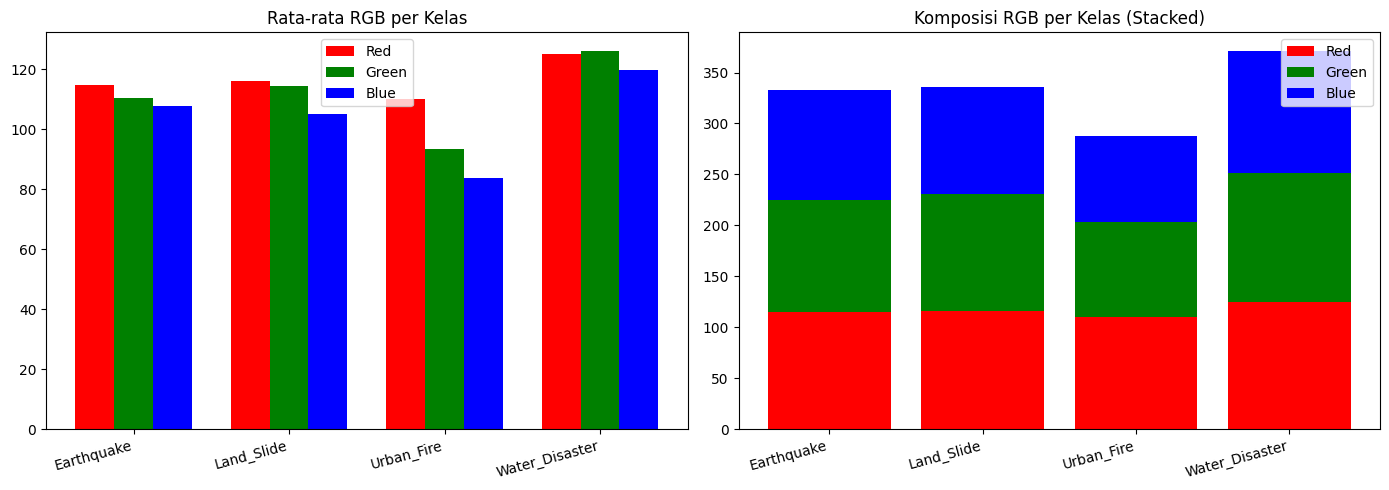

In [ ]:
kelas_list = list(mean_rgb.keys())
r_vals = [mean_rgb[k]['R'] for k in kelas_list]
g_vals = [mean_rgb[k]['G'] for k in kelas_list]
b_vals = [mean_rgb[k]['B'] for k in kelas_list]

x = np.arange(len(kelas_list))
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - w, r_vals, w, label='Red',   color='red')
axes[0].bar(x,     g_vals, w, label='Green', color='green')
axes[0].bar(x + w, b_vals, w, label='Blue',  color='blue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(kelas_list, rotation=15, ha='right')
axes[0].set_title('Rata-rata RGB per Kelas')
axes[0].legend()

axes[1].bar(kelas_list, r_vals, label='Red',   color='red')
axes[1].bar(kelas_list, g_vals, bottom=r_vals, label='Green', color='green')
axes[1].bar(kelas_list, b_vals, bottom=[r+g for r,g in zip(r_vals, g_vals)], label='Blue', color='blue')
axes[1].set_xticklabels(kelas_list, rotation=15, ha='right')
axes[1].set_title('Komposisi RGB per Kelas (Stacked)')
axes[1].legend()

plt.tight_layout()
plt.show()

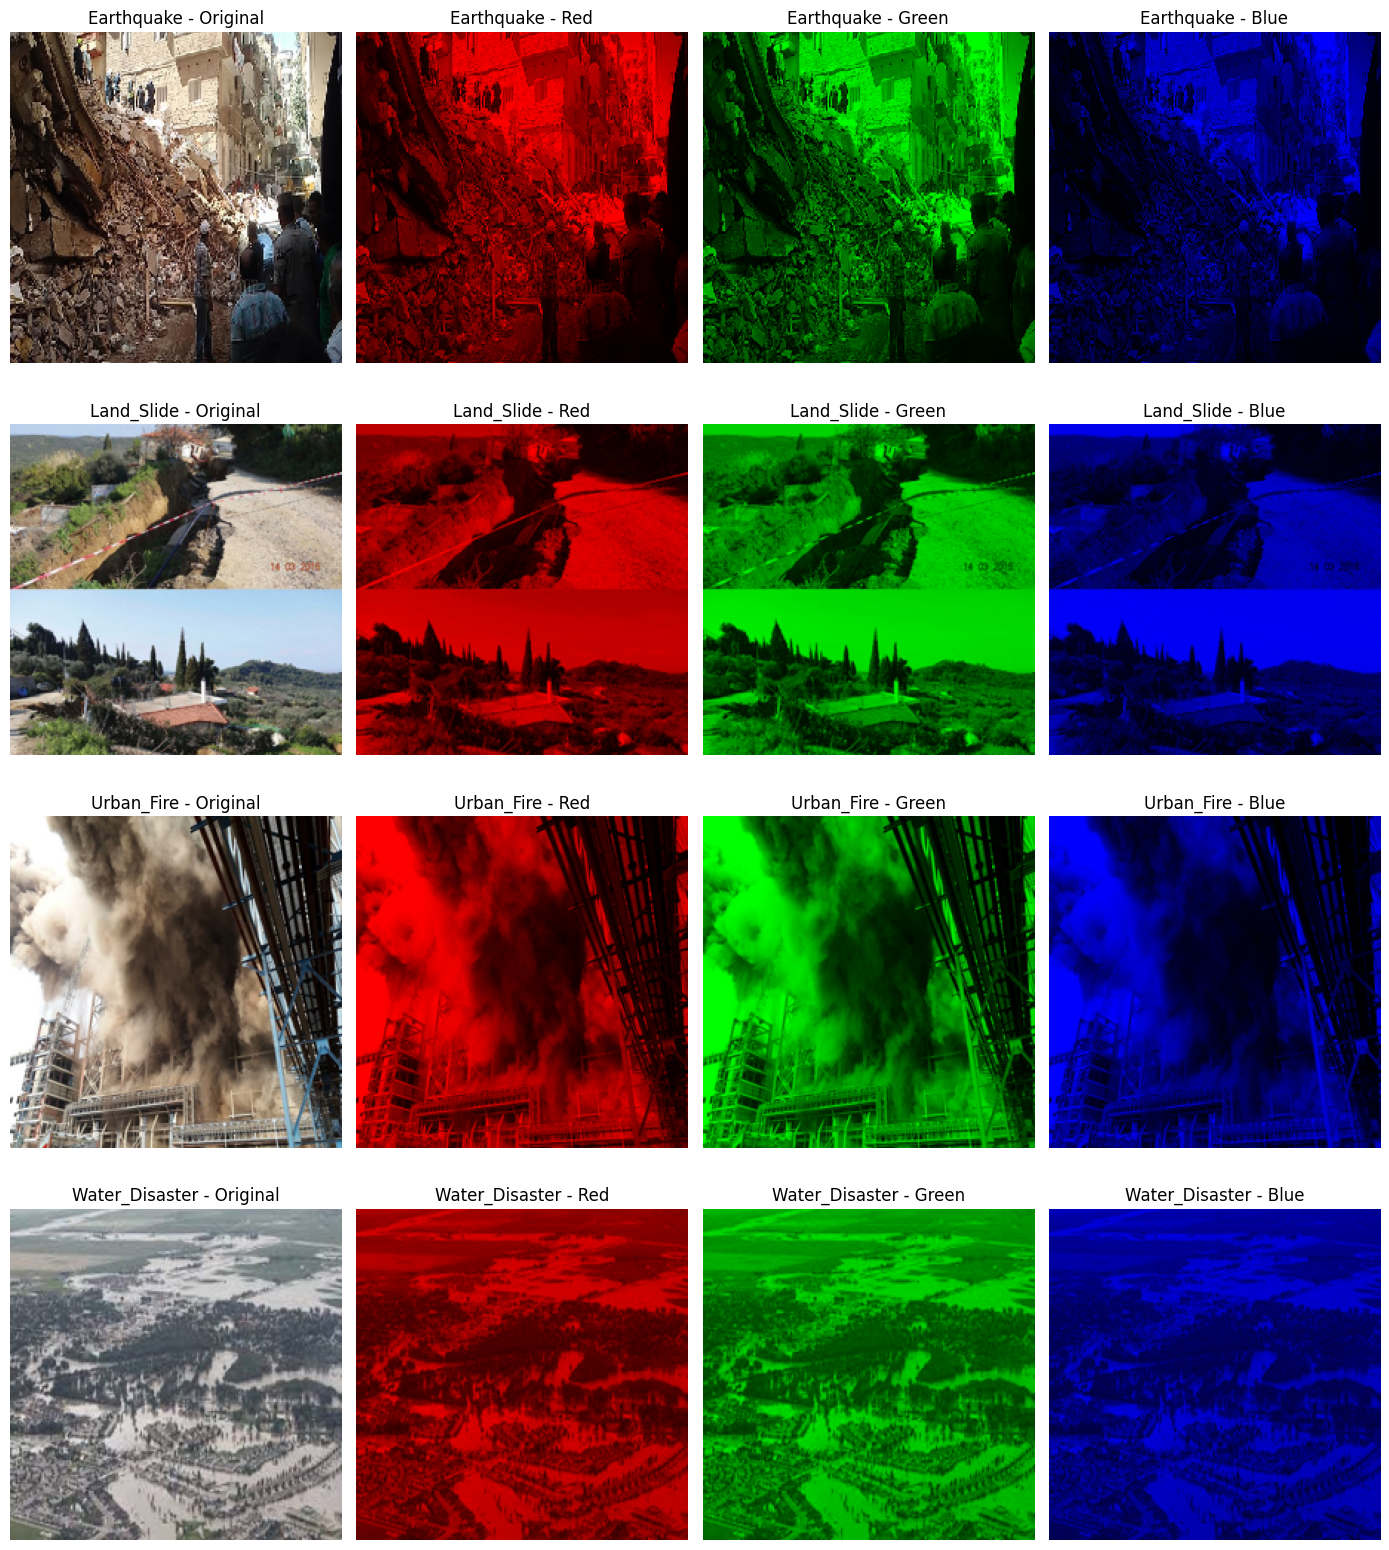

In [ ]:
fig, axes = plt.subplots(len(kelas_bencana), 4, figsize=(14, 4 * len(kelas_bencana)))
ch_labels = ['Original', 'Red', 'Green', 'Blue']

for i, kelas in enumerate(kelas_bencana):
    lokasi_folder = os.path.join(DATA_DIR, kelas)
    list_gambar = [f for f in os.listdir(lokasi_folder)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    arr = np.array(Image.open(os.path.join(lokasi_folder, random.choice(list_gambar))).convert('RGB').resize((224, 224)))

    for j in range(4):
        if j == 0:
            axes[i, j].imshow(arr)
        else:
            ch_img = np.zeros_like(arr)
            ch_img[:, :, j-1] = arr[:, :, j-1]
            axes[i, j].imshow(ch_img)
        axes[i, j].set_title(f'{kelas} - {ch_labels[j]}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# Data Preparation

Dari EDA tadi kita udah tau masalahnya: ukuran gambar beda-beda, datanya ga seimbang, dan gambarnya berasal dari berbagai sumber.

Bagian ini yang ngatasinnya: split data, augmentasi, normalisasi, dan nyari class weight yang optimal lewat Bayesian Optimization.

kila

In [ ]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

val_test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

val_batches = len(val_test_ds_raw) // 2
val_ds_raw  = val_test_ds_raw.take(val_batches)
test_ds_raw = val_test_ds_raw.skip(val_batches)

CLASS_NAMES = train_ds_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)

print(f"Kelas ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_ds_raw)} batch  \nVal: {len(val_ds_raw)} batch \nTest: {len(test_ds_raw)} batch")

Found 2345 files belonging to 4 classes.
Using 1876 files for training.
Found 2345 files belonging to 4 classes.
Using 469 files for validation.
Kelas (4): ['Earthquake', 'Land_Slide', 'Urban_Fire', 'Water_Disaster']
Train: 59 batch  
Val: 7 batch 
Test: 8 batch


**Inshigt:**

Split berhasil: 59 batch training, 7 batch validation, 8 batch test (245 gambar). Sekarang lanjut define augmentasi dan normalisasi untuk CNN Scratch (gambar di-rescale ke range 0–1)


kila

In [ ]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.15, seed=SEED),
    layers.RandomZoom(0.1, seed=SEED),
    layers.RandomContrast(0.1, seed=SEED),
    layers.RandomTranslation(0.1, 0.1, seed=SEED),
])

normalization = layers.Rescaling(1.0 / 255)

def preprocess_train(image, label):
    return normalization(data_augmentation(image, training=True)), label

def preprocess_val(image, label):
    return normalization(image), label

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_raw.map(preprocess_train, num_parallel_calls=AUTOTUNE).shuffle(1000, seed=SEED, reshuffle_each_iteration=False).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.map(preprocess_val, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.map(preprocess_val, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

kila

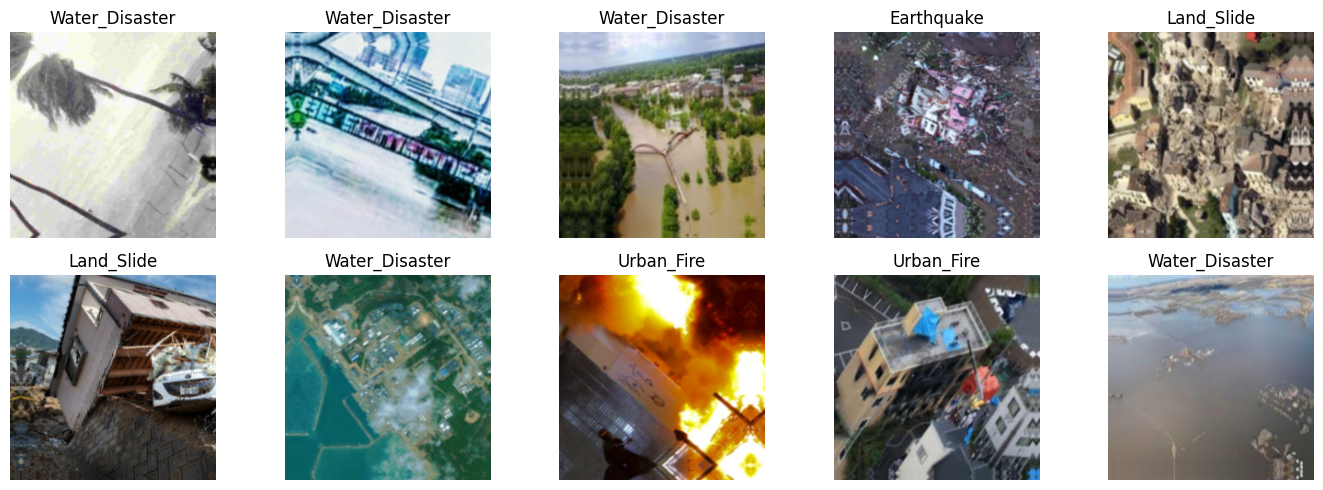

Shape: (32, 224, 224, 3), min=0.000, max=1.000


In [ ]:
# CCek hasil augmentasi
# Pastikan augmentasi & normalisasi berjalan benar sebelum lanjut training
images, labels = next(iter(train_ds))

plt.figure(figsize=(14, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(CLASS_NAMES[np.argmax(labels[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Shape: {images.shape}, min={images.numpy().min():.3f}, max={images.numpy().max():.3f}")

**Inshigt:**

Augmentasi yang dipakai: flip horizontal, rotasi ±15°, zoom ±10%, contrast ±10%, dan translasi ±10%. Augmentasi cuma diterapkan di training set, validation dan test set cuma dinormalisasi tanpa diubah

# Model Scratch

mimi

In [ ]:
#handle imbalance
try:
    from skopt import gp_minimize
    from skopt.space import Real
    from skopt.utils import use_named_args
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "scikit-optimize", "-q"], check=True)
    from skopt import gp_minimize
    from skopt.space import Real
    from skopt.utils import use_named_args

import numpy as np
from sklearn.metrics import f1_score

def build_proxy_model():
    from tensorflow.keras import layers, models
    m = models.Sequential([
        tf.keras.Input(shape=(224, 224, 3)),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def evaluate_weights(weights_dict, epochs=12):
    set_seed(SEED)
    proxy = build_proxy_model()
    proxy.fit(train_ds, validation_data=val_ds,
              epochs=epochs, class_weight=weights_dict, verbose=0)
    y_true, y_pred = [], []
    for images, labels in val_ds:
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(proxy.predict(images, verbose=0), axis=1))
    f1 = f1_score(y_true, y_pred, average='macro')
    del proxy
    tf.keras.backend.clear_session()
    return f1

search_space = [
    Real(0.5, 2.5, name='w_earthquake'),
    Real(0.5, 3.5, name='w_land_slide'),
    Real(0.5, 3.0, name='w_urban_fire'),
    Real(0.5, 1.8, name='w_water_disaster'),
]

call_count = [0]

@use_named_args(search_space)
def objective(w_earthquake, w_land_slide, w_urban_fire, w_water_disaster):
    weights = {0: w_earthquake, 1: w_land_slide,
               2: w_urban_fire, 3: w_water_disaster}
    call_count[0] += 1
    f1 = evaluate_weights(weights, epochs=5)
    print(f"  [{call_count[0]:2d}] weights={[f'{v:.2f}' for v in weights.values()]}  F1 Macro={f1:.4f}")
    return -f1


print("MULAI BAYESIAN OPTIMIZATION CLASS WEIGHTS")


result_bayes = gp_minimize(
    func=objective,
    dimensions=search_space,
    n_calls=50,
    n_initial_points=10,
    acq_func='LCB',
    random_state=SEED,
    verbose=False
)

best = result_bayes.x
best_f1 = -result_bayes.fun

class_weight = {0: best[0], 1: best[1], 2: best[2], 3: best[3]}

print(f"\nBest F1 Macro : {best_f1:.4f}")
print(f"earthquake    : {class_weight[0]:.4f}")
print(f"land_slide    : {class_weight[1]:.4f}")
print(f"urban_fire    : {class_weight[2]:.4f}")
print(f"water_disaster: {class_weight[3]:.4f}")

MULAI BAYESIAN OPTIMIZATION CLASS WEIGHTS
  [ 1] weights=['1.08', '1.61', '1.90', '0.50']  F1 Macro=0.2557
  [ 2] weights=['1.49', '0.55', '1.65', '1.64']  F1 Macro=0.3127
  [ 3] weights=['0.78', '1.62', '1.85', '1.08']  F1 Macro=0.4050
  [ 4] weights=['1.91', '1.97', '2.32', '0.89']  F1 Macro=0.5075
  [ 5] weights=['0.81', '1.25', '2.86', '0.92']  F1 Macro=0.3605
  [ 6] weights=['1.20', '1.39', '1.83', '1.76']  F1 Macro=0.3167
  [ 7] weights=['2.26', '3.07', '0.95', '0.53']  F1 Macro=0.3081
  [ 8] weights=['1.27', '2.42', '1.57', '0.98']  F1 Macro=0.3096
  [ 9] weights=['0.92', '2.14', '1.18', '1.25']  F1 Macro=0.3499
  [10] weights=['2.15', '2.99', '2.45', '0.60']  F1 Macro=0.2585
  [11] weights=['1.84', '1.07', '2.30', '0.82']  F1 Macro=0.2525
  [12] weights=['1.88', '2.12', '2.91', '1.27']  F1 Macro=0.4875
  [13] weights=['1.98', '2.08', '1.54', '1.68']  F1 Macro=0.5090
  [14] weights=['2.06', '1.86', '1.80', '0.71']  F1 Macro=0.3844
  [15] weights=['1.96', '2.27', '2.40', '0.63'] 

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [2.5, 3.5, 3.0, 1.8] before, using random point [1.5894977910296997, 1.584673239641962, 1.8855544581876753, 0.5369508320241226]
  warnings.warn(


  [46] weights=['1.59', '1.58', '1.89', '0.54']  F1 Macro=0.4153


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [2.5, 3.5, 3.0, 1.8] before, using random point [1.6948211959743498, 2.712575186595467, 2.3167612977881626, 1.175383558994386]
  warnings.warn(


  [47] weights=['1.69', '2.71', '2.32', '1.18']  F1 Macro=0.2520


...

  [48] weights=['1.74', '1.34', '1.79', '1.72']  F1 Macro=0.4913


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [2.5, 3.5, 3.0, 1.8] before, using random point [1.0204372445966792, 2.8625067641454995, 1.563795571862356, 0.8184330468321616]
  warnings.warn(


  [49] weights=['1.02', '2.86', '1.56', '0.82']  F1 Macro=0.3060


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [2.5, 3.5, 3.0, 1.8] before, using random point [0.5448578242230222, 1.8156621239114394, 2.7099006412044866, 1.5455029570813161]
  warnings.warn(


  [50] weights=['0.54', '1.82', '2.71', '1.55']  F1 Macro=0.2845

Best F1 Macro : 0.5863
earthquake    : 2.5000
land_slide    : 3.2854
urban_fire    : 2.6682
water_disaster: 1.8000


In [ ]:
# CNN

import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([


    tf.keras.Input(shape=(320, 320, 3)),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.LeakyReLU(alpha=0.1),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    #layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.1),

    # Block 4
    layers.Conv2D(250, (3,3), padding='same', activation='relu'),
    #layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Instead of Flatten()
    layers.GlobalAveragePooling2D(),

    #layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(4, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 320, 320, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 320, 320, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 40, 250)    │       288,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 20, 250)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 250)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,398 (1.58 MB)

 Trainable params: 414,270 (1.58 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# COMPILE MODEL

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=0.001
    ),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy']
)

callbacks_scratch = [
    EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True
    )
]

history_scratch = model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=callbacks_scratch,
    class_weight=class_weight,
    epochs=50)

print(f"Epoch terbaik : {np.argmax(history_scratch.history['val_accuracy']) + 1}")
print(f"Val accuracy  : {max(history_scratch.history['val_accuracy']):.4f}")

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 31s 261ms/step - accuracy: 0.4632 - loss: 2.9088 - val_accuracy: 0.4286 - val_loss: 1.3401
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.5602 - loss: 2.5047 - val_accuracy: 0.2411 - val_loss: 1.3190
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.5752 - loss: 2.4353 - val_accuracy: 0.2545 - val_loss: 1.3402
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.5842 - loss: 2.4159 - val_accuracy: 0.5759 - val_loss: 1.2119
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.5885 - loss: 2.3460 - val_accuracy: 0.5580 - val_loss: 1.1587
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.6087 - loss: 2.3043 - val_accuracy: 0.5938 - val_loss: 1.0524
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.6007 - loss: 2.2999 - val_accuracy: 0.2589 - val_loss: 1.6853
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.6194 - loss: 2.2655 - val_accuracy: 0.4598 

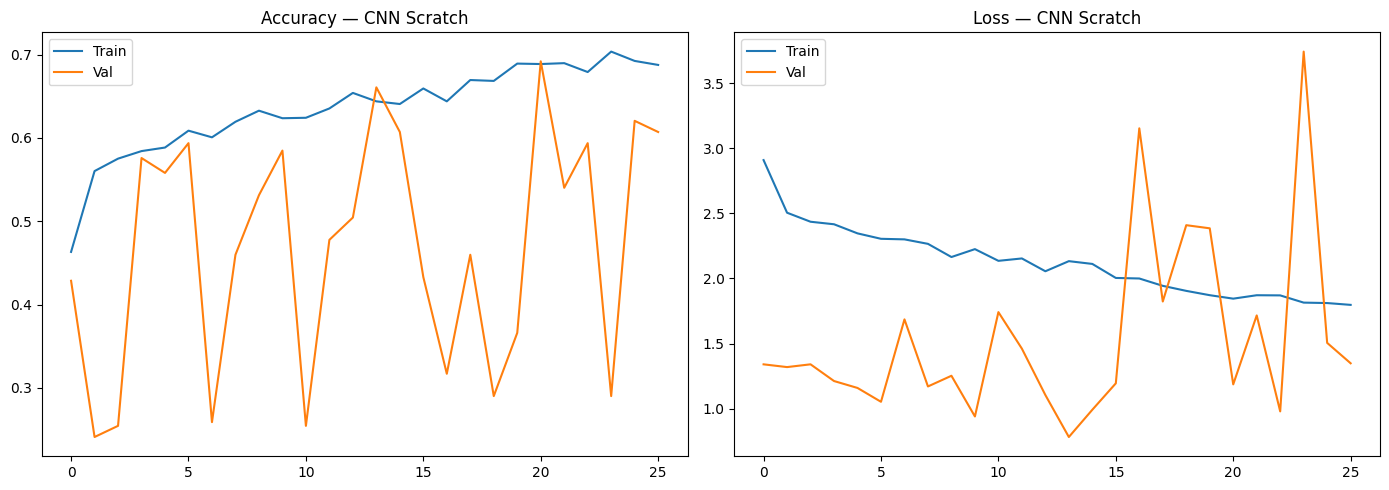

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_scratch.history['accuracy'], label='Train')
axes[0].plot(history_scratch.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy — CNN Scratch')
axes[0].legend()

axes[1].plot(history_scratch.history['loss'], label='Train')
axes[1].plot(history_scratch.history['val_loss'], label='Val')
axes[1].set_title('Loss — CNN Scratch')
axes[1].legend()

plt.tight_layout()
plt.show()

Grafik Accuracy (kiri): Garis train (biru) naik stabil dari ~0.46 sampai ~0.69, tapi garis val (oranye) sangat fluktuatif — naik-turun ekstrem di hampir setiap epoch. Ini tanda jelas overfitting: model makin jago di data training tapi hasilnya nggak konsisten di data validasi.
Grafik Loss (kanan): Ada fenomena menarik di sini — val loss (oranye) justru lebih rendah dari train loss (biru) di awal training. Ini karena efek class weighting dari Bayesian Optimization: penalti di training sengaja dibesarkan untuk kelas minoritas, jadi train loss kelihatan lebih tinggi. Tapi setelah epoch ~13, val loss mulai lompat-lompat nggak stabil, bahkan sempat melonjak ke ~3.7 di sekitar epoch 22 — konsisten dengan fluktuasi accuracy validasi.
Kesimpulannya: model scratch kesulitan generalisasi. Overfitting terjadi karena kapasitas model terbatas + data yang nggak banyak. Ini jadi motivasi kuat untuk coba transfer learning.

In [ ]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

y_true_all, y_pred_scratch = [], []
for images, labels in test_ds:
    y_true_all.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_scratch.extend(np.argmax(model.predict(images, verbose=0), axis=1))

y_true_all     = np.array(y_true_all)
y_pred_scratch = np.array(y_pred_scratch)

print(f"Accuracy: {accuracy_score(y_true_all, y_pred_scratch):.4f}")
print(f"F1 Macro: {f1_score(y_true_all, y_pred_scratch, average='macro'):.4f}")
print(classification_report(y_true_all, y_pred_scratch, target_names=CLASS_NAMES, digits=4))

Accuracy: 0.6449
F1 Macro: 0.6527
                precision    recall  f1-score   support

    Earthquake     0.6800    0.6667    0.6733        51
    Land_Slide     0.3780    0.7045    0.4921        44
    Urban_Fire     1.0000    0.6000    0.7500        35
Water_Disaster     0.7826    0.6261    0.6957       115

      accuracy                         0.6449       245
     macro avg     0.7102    0.6493    0.6527       245
  weighted avg     0.7196    0.6449    0.6622       245



Overall accuracy 64.49% dengan F1 Macro 0.6527 di 245 gambar test.

Yang paling menarik perhatian adalah Urban_Fire — precision-nya 1.0000 alias sempurna! Artinya setiap kali model prediksi "ini kebakaran", dia selalu benar tanpa satu pun false positive. Tapi recall-nya cuma 0.60, jadi 40% gambar kebakaran masih kelewat dan salah diklasifikasi ke kelas lain.

Land_Slide punya pola kebalikannya — recall tinggi (0.70) tapi precision rendah (0.38). Artinya model "terlalu agresif" nge-label sesuatu sebagai longsor, banyak gambar dari kelas lain ikut terseret masuk. Ini efek dari class weight
Land_Slide yang tinggi (2.25) hasil Bayesian Optimization — model jadi oversensitif ke kelas ini.

Water_Disaster precision-nya bagus (0.78) tapi recall-nya lebih rendah (0.63) — dari 115 gambar banjir, sekitar 43 gambar salah prediksi.

Earthquake paling seimbang antara precision (0.68) dan recall (0.67), F1-nya 0.67.
Kesimpulan: class weighting berhasil angkat recall Land_Slide yang tadinya cuma 0.25 (versi tanpa weighting) jadi 0.70, tapi "harganya" adalah precision yang jatuh. Trade-off yang wajar untuk kelas minoritas.

# Transfer Learning

EfficientNetB0 butuh pipeline data tersendiri karena preprocessing-nya beda (gambar nggak di-rescale), dibiarkan di range 0–255 supaya preprocessing internal backbonenya bisa jalan

kila

In [ ]:
# DATASET KHUSUS EFFICIENTNET
# EfficientNetB0 sudah punya preprocessing internal
# Input HARUS [0, 255], jangan Rescaling lagi!
data_augmentation_effnet = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    layers.RandomRotation(0.2, seed=SEED),
    layers.RandomZoom(0.15, seed=SEED),
    layers.RandomContrast(0.2, seed=SEED),
    layers.RandomTranslation(0.1, 0.1, seed=SEED),
    layers.RandomBrightness(0.1, seed=SEED),
])

def preprocess_train_effnet(image, label):
    return data_augmentation_effnet(tf.cast(image, tf.float32), training=True), label

def preprocess_val_effnet(image, label):
    return tf.cast(image, tf.float32), label

train_ds_effnet = train_ds_raw.map(preprocess_train_effnet, num_parallel_calls=AUTOTUNE).cache().shuffle(1000, seed=SEED, reshuffle_each_iteration=False).prefetch(AUTOTUNE)
val_ds_effnet   = val_ds_raw.map(preprocess_val_effnet, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds_effnet  = test_ds_raw.map(preprocess_val_effnet, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

Augmentasinya lebih agresif dari CNN Scratch, ditambah flip vertikal, rotasi ±20%, zoom ±15%, contrast ±20%, dan brightness ±10% karena backbone pretrainednya lebih tahan terhadap variasi gambar

kila

In [ ]:
# Bangun Arsitektur EFFICIENTNETB0
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs  = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_effnet = models.Model(inputs, outputs, name="EfficientNetB0_Transfer")
model_effnet.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "EfficientNetB0_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,842,919 (18.47 MB)

 Trainable params: 790,788 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Arsitektur head-nya: GlobalAveragePooling → BatchNorm → Dense 512 → Dropout 0.4 → Dense 256 → Dropout 0.3 → Dense 4 softmax. Backbone EfficientNetB0 dikunci dulu (trainable=False), jadi yang dilatih cuma bagian atasnya.

kila

In [ ]:
# Training EfficientNet Stage 1

model_effnet.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_effnet = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/PROJECT_DL/model_effnet_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_effnet_s1 = model_effnet.fit(
    train_ds_effnet, validation_data=val_ds_effnet,
    epochs=25, callbacks=callbacks_effnet, class_weight=class_weight, verbose=1
)
print(f"Val accuracy terbaik : {max(history_effnet_s1.history['val_accuracy']):.4f}")

Epoch 1/25
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.4901 - loss: 3.4922
Epoch 1: val_accuracy improved from None to 0.80357, saving model to /content/drive/MyDrive/PROJECT_DL/model_effnet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PROJECT_DL/model_effnet_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 99s 594ms/step - accuracy: 0.5853 - loss: 2.9894 - val_accuracy: 0.8036 - val_loss: 0.9777 - learning_rate: 5.0000e-04
Epoch 2/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7289 - loss: 2.1723
Epoch 2: val_accuracy improved from 0.80357 to 0.81250, saving model to /content/drive/MyDrive/PROJECT_DL/model_effnet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PROJECT_DL/model_effnet_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 57s 59ms/step - accuracy: 0.7479 - loss: 2.1612 - val_accuracy: 0.8125 - val_loss: 0.9166 - learning_rate: 5.0000e-04
Epoch 3/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8283 - loss: 1.8285
Epoch 3: v

Stage 1 selesai. Dari epoch 1 val accuracy udah langsung 80%, ini bukti nyata efeknya pretrained weights

Sekarang buat lanjut ke stage 2: 30 layer terakhir backbone dibuka, tapi learning rate-nya dikecilkan ke 1e-5 biar bobotnya nggak rusak

kila

In [ ]:
# fine-tuning stage 2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model_effnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_effnet_s2 = model_effnet.fit(
    train_ds_effnet, validation_data=val_ds_effnet,
    epochs=30, callbacks=callbacks_effnet, class_weight=class_weight, verbose=1
)
print(f"Val accuracy terbaik stage 2 : {max(history_effnet_s2.history['val_accuracy']):.4f}")

Epoch 1/30
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.8450 - loss: 1.7208
Epoch 1: val_accuracy improved from 0.85268 to 0.85714, saving model to /content/drive/MyDrive/PROJECT_DL/model_effnet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PROJECT_DL/model_effnet_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 61s 500ms/step - accuracy: 0.8619 - loss: 1.7027 - val_accuracy: 0.8571 - val_loss: 0.7840 - learning_rate: 1.0000e-05
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8691 - loss: 1.6684
Epoch 2: val_accuracy did not improve from 0.85714
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8779 - loss: 1.6260 - val_accuracy: 0.8482 - val_loss: 0.8120 - learning_rate: 1.0000e-05
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8883 - loss: 1.5571
Epoch 3: val_accuracy did not improve from 0.85714
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.8891 - loss: 1.5767 - val_accuracy: 0.8259 - val_loss: 0.8340 - learning_ra

Stage 2 mulai dari val accuracy ~85%. Learning rate kecil bikin perubahan bobot lebih halus, model fine-tuning perlahan ke domain bencana tanpa lupain apa yang udah dipelajari dari ImageNet

kila

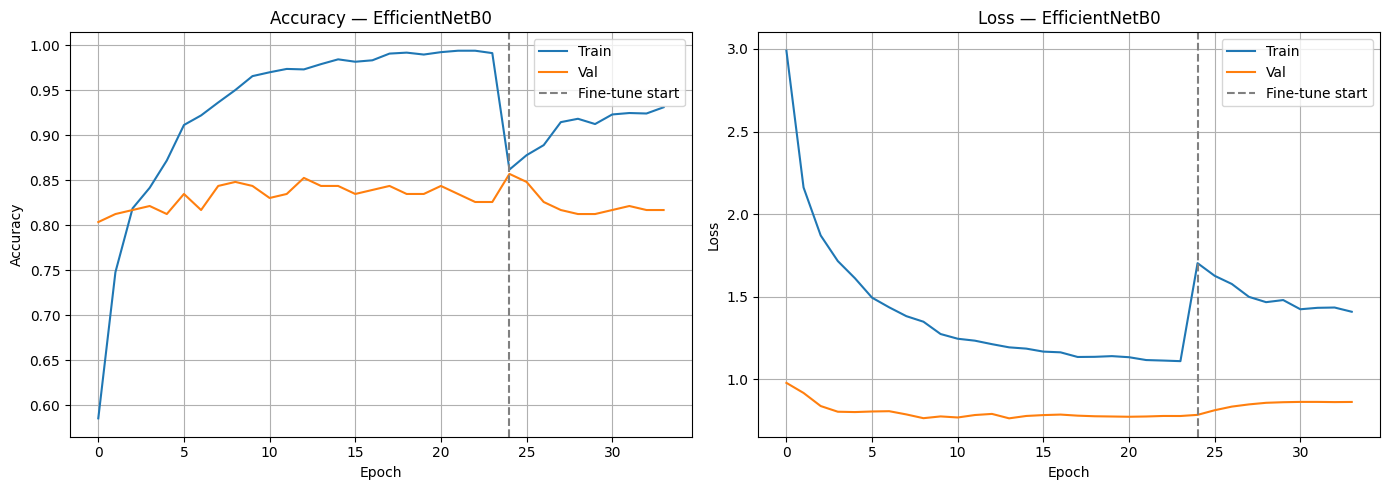

In [ ]:
# Plot Training History EfficientNetB0

total_acc   = history_effnet_s1.history['accuracy']     + history_effnet_s2.history['accuracy']
total_vacc  = history_effnet_s1.history['val_accuracy'] + history_effnet_s2.history['val_accuracy']
total_loss  = history_effnet_s1.history['loss']         + history_effnet_s2.history['loss']
total_vloss = history_effnet_s1.history['val_loss']     + history_effnet_s2.history['val_loss']

garis_finetune = len(history_effnet_s1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, train, val, title in zip(axes,
                                  [total_acc, total_loss],
                                  [total_vacc, total_vloss],
                                  ['Accuracy', 'Loss']):
    ax.plot(train, label='Train')
    ax.plot(val,   label='Val')
    ax.axvline(garis_finetune, color='gray', linestyle='--', label='Fine-tune start')
    ax.set_title(f'{title} — EfficientNetB0')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

**Inshigt::**

***Accuracy:***

Stage 1: train naik cepat dari ~59% sampai hampir 100%, tapi val cuma naik sampai ~84–85% dan relatif flat, ada gap besar antara train dan val, ini tanda overfitting di Stage 1

Stage 2: train accuracy drop drastis dulu ke ~85% waktu fine-tuning mulai (karena beberapa layer backbone dibuka ulang), terus naik lagi ke ~93%. Val accuracy justru tidak naik signifikan, tetap di ~81–82%


***Loss:***

Stage 1: train loss turun drastis, val loss juga turun tapi jauh lebih tinggi dari train loss, ngekonfirmasi overfitting

Stage 2: ada spike kecil di awal fine-tuning, terus keduanya stabil di angka yang lebih rendah

kila

In [ ]:
# classifcation report
from sklearn.metrics import classification_report, f1_score, accuracy_score
import numpy as np

y_true_all, y_pred_effnet = [], []

for images, labels in test_ds_effnet:
    y_true_all.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_effnet.extend(np.argmax(model_effnet.predict(images, verbose=0), axis=1))

y_true_all    = np.array(y_true_all)
y_pred_effnet = np.array(y_pred_effnet)

print(f"Accuracy : {accuracy_score(y_true_all, y_pred_effnet):.4f}")
print(f"F1 Macro : {f1_score(y_true_all, y_pred_effnet, average='macro'):.4f}")

print(classification_report(y_true_all, y_pred_effnet, target_names=CLASS_NAMES, digits=4))

Accuracy : 0.8245
F1 Macro : 0.8098
                precision    recall  f1-score   support

    Earthquake     0.7818    0.7963    0.7890        54
    Land_Slide     0.6531    0.6667    0.6598        48
    Urban_Fire     0.8667    0.9286    0.8966        28
Water_Disaster     0.9099    0.8783    0.8938       115

      accuracy                         0.8245       245
     macro avg     0.8029    0.8174    0.8098       245
  weighted avg     0.8264    0.8245    0.8252       245



# Evaluation

mimi

In [ ]:
y_true_all, y_pred_scratch = [], []
for images, labels in test_ds:
    y_true_all.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_scratch.extend(np.argmax(model.predict(images, verbose=0), axis=1))

y_true_effnet, y_pred_effnet = [], []
for images, labels in test_ds_effnet:
    y_true_effnet.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_effnet.extend(np.argmax(model_effnet.predict(images, verbose=0), axis=1))

y_true_all    = np.array(y_true_all);    y_pred_scratch = np.array(y_pred_scratch)
y_true_effnet = np.array(y_true_effnet); y_pred_effnet  = np.array(y_pred_effnet)

print(f"Accuracy  — CNN Scratch: {accuracy_score(y_true_all, y_pred_scratch):.4f} | EfficientNetB0: {accuracy_score(y_true_effnet, y_pred_effnet):.4f}")
print(f"F1 Macro  — CNN Scratch: {f1_score(y_true_all, y_pred_scratch, average='macro'):.4f} | EfficientNetB0: {f1_score(y_true_effnet, y_pred_effnet, average='macro'):.4f}")

print("\nClassification Report — CNN Scratch")
print(classification_report(y_true_all, y_pred_scratch, target_names=CLASS_NAMES, digits=4))

print("Classification Report — EfficientNetB0")
print(classification_report(y_true_effnet, y_pred_effnet, target_names=CLASS_NAMES, digits=4))

Accuracy  — CNN Scratch: 0.6449 | EfficientNetB0: 0.8245
F1 Macro  — CNN Scratch: 0.6527 | EfficientNetB0: 0.8098

Classification Report — CNN Scratch
                precision    recall  f1-score   support

    Earthquake     0.6800    0.6667    0.6733        51
    Land_Slide     0.3780    0.7045    0.4921        44
    Urban_Fire     1.0000    0.6000    0.7500        35
Water_Disaster     0.7826    0.6261    0.6957       115

      accuracy                         0.6449       245
     macro avg     0.7102    0.6493    0.6527       245
  weighted avg     0.7196    0.6449    0.6622       245

Classification Report — EfficientNetB0
                precision    recall  f1-score   support

    Earthquake     0.7818    0.7963    0.7890        54
    Land_Slide     0.6531    0.6667    0.6598        48
    Urban_Fire     0.8667    0.9286    0.8966        28
Water_Disaster     0.9099    0.8783    0.8938       115

      accuracy                         0.8245       245
     macro avg     0.

EfficientNetB0 unggul di semua metrik — accuracy naik dari 64.49% → 82.45% (+17.9 poin) dan F1 Macro dari 0.6527 → 0.8098 (+15.7 poin).

Perbaikan paling drastis ada di Land_Slide: precision naik dari 0.38 → 0.65. Di CNN scratch, model terlalu "trigger-happy" label longsor karena class weight tinggi, jadi banyak false positive. EfficientNetB0 jauh lebih selektif dan tetap punya recall yang bagus (0.67) — trade-off precision-recall yang lebih seimbang.


Urban_Fire di scratch precision-nya sempurna (1.0) tapi recall cuma 0.60. Di EfficientNet justru sebaliknya jadi lebih seimbang: precision 0.87 dan recall 0.93 — model sekarang bisa nangkep hampir semua gambar kebakaran tanpa banyak false positive. F1-nya naik dari 0.75 → 0.90.

Water_Disaster juga meningkat signifikan: F1 dari 0.70 → 0.89, dengan precision 0.91 yang artinya model sangat jarang salah kalau prediksi banjir.

Earthquake naik solid dari F1 0.67 → 0.79.
Satu-satunya kelas yang masih jadi titik lemah di kedua model adalah Land_Slide (F1 tertinggi hanya 0.66 di EfficientNet) — konsisten karena secara visual memang paling mirip dengan Earthquake.

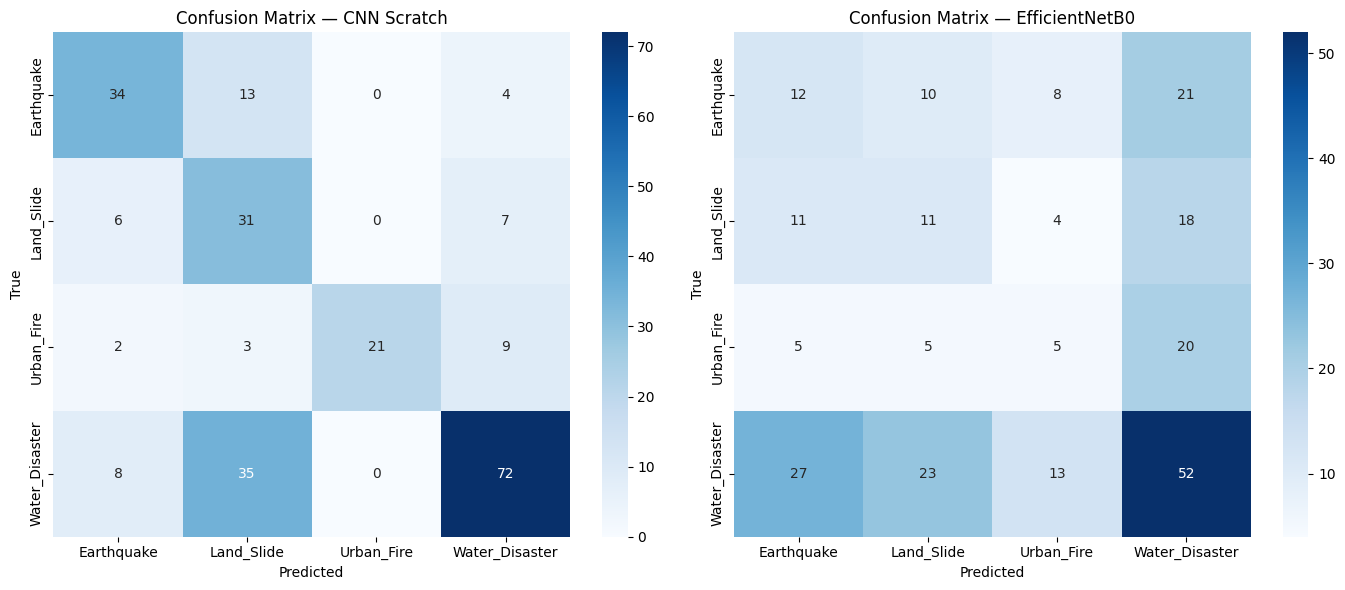

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, judul in zip(axes, [y_pred_scratch, y_pred_effnet], ['CNN Scratch', 'EfficientNetB0']):
    sns.heatmap(confusion_matrix(y_true_all, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix — {judul}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

CNN Scratch (kiri):
Diagonal menunjukkan prediksi benar: Earthquake 34, Land_Slide 31, Urban_Fire 21, Water_Disaster 72. Error terbesar ada di baris Water_Disaster — 35 gambar banjir salah diprediksi sebagai Land_Slide. Ini konsisten dengan class weight Land_Slide yang tinggi, jadi model terlalu agresif nge-label sesuatu sebagai longsor. Urban_Fire juga cukup bermasalah: 9 dari 35 gambar kebakaran salah jadi Water_Disaster. Satu hal yang menarik: kolom Urban_Fire hampir kosong di scratch kecuali diagonalnya — artinya model sangat jarang memprediksi "kebakaran", makanya precision-nya 1.0 tapi recall-nya rendah.


EfficientNetB0 (kanan):
Secara keseluruhan warna diagonal lebih gelap relatif terhadap off-diagonal — tanda prediksi yang lebih baik. Tapi ada pola error yang menarik: Earthquake justru paling berantakan di EfficientNet, dengan 21 gambar gempa salah diprediksi sebagai Water_Disaster dan 10 lainnya salah ke Land_Slide. Hanya 12 dari 54 yang benar — ini yang bikin recall Earthquake "cuma" 0.79 padahal model lain sudah bagus. Land_Slide juga masih sering ketuker dengan Earthquake (11 salah) dan Water_Disaster (18 salah) — konfirmasi bahwa ketiga kelas ini memang paling susah dibedain secara visual.


Kesimpulan: CNN Scratch struggle di Water_Disaster yang sering salah dikira Land_Slide, sedangkan EfficientNet lebih merata tapi masih lemah membedakan Earthquake dari Water_Disaster.

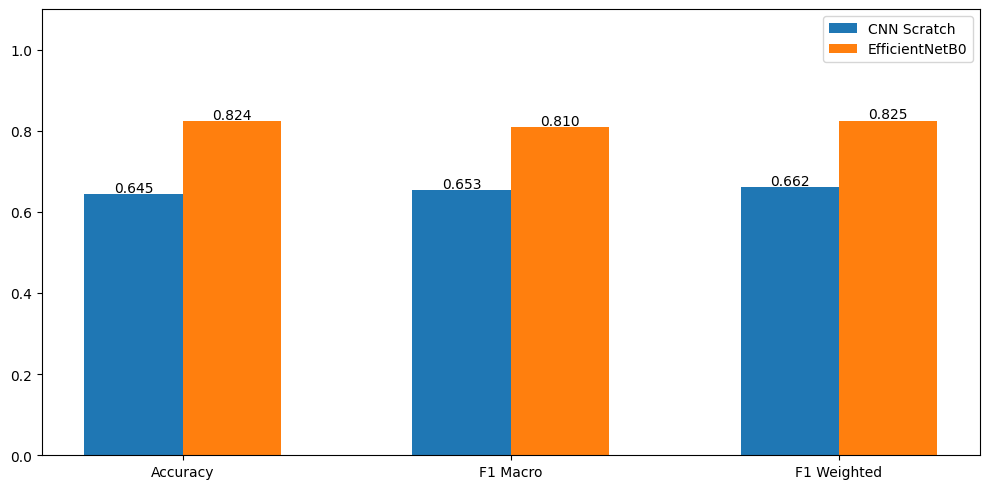

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score

# 1. Definisikan dan hitung akurasi terlebih dahulu menggunakan accuracy_score
acc_scratch = accuracy_score(y_true_all, y_pred_scratch)
acc_effnet = accuracy_score(y_true_effnet, y_pred_effnet)

# 2. Masukkan variabel yang sudah dihitung ke dalam dictionary metrics
metrics = {
    'Accuracy'   : [acc_scratch, acc_effnet],
    'F1 Macro'   : [f1_score(y_true_all, y_pred_scratch, average='macro'),
                    f1_score(y_true_effnet, y_pred_effnet, average='macro')],
    'F1 Weighted': [f1_score(y_true_all, y_pred_scratch, average='weighted'),
                    f1_score(y_true_effnet, y_pred_effnet, average='weighted')],
}

# 3. Proses plotting grafik bar
x, width = np.arange(len(metrics)), 0.3
fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, [v[0] for v in metrics.values()], width, label='CNN Scratch')
bars2 = ax.bar(x + width/2, [v[1] for v in metrics.values()], width, label='EfficientNetB0')

for bar in [bars1, bars2]:
    for rect in bar:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.005, f'{h:.3f}', ha='center')

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

Grafik ini nunjukin perbandingan head-to-head ketiga metrik utama antara CNN Scratch (biru) dan EfficientNetB0 (oranye).
EfficientNetB0 menang di semua metrik tanpa pengecualian:

Accuracy: 0.645 → 0.824 (+17.9 poin)

F1 Macro: 0.653 → 0.810 (+15.7 poin)

F1 Weighted: 0.662 → 0.825 (+16.3 poin)

Yang menarik, gap antara F1 Macro dan F1 Weighted di EfficientNetB0 sangat kecil (0.810 vs 0.825) — artinya model performanya konsisten merata di semua kelas, nggak cuma jago di kelas yang datanya banyak. Bandingkan sama CNN Scratch yang gap-nya juga kecil tapi di level yang jauh lebih rendah.
Kesimpulan visual yang langsung keliatan: bar oranye konsisten ~27% lebih tinggi dari bar biru di semua metrik — ini konfirmasi kuat bahwa transfer learning dengan EfficientNetB0 adalah pilihan yang jauh lebih superior untuk dataset bencana kita yang ukurannya terbatas.

kila

In [ ]:
import numpy as np

y_true_all, y_prob_scratch = [], []
for images, labels in test_ds:
    y_true_all.extend(np.argmax(labels.numpy(), axis=1))
    y_prob_scratch.extend(model.predict(images, verbose=0))

y_true_effnet, y_prob_effnet = [], []
for images, labels in test_ds_effnet:
    y_true_effnet.extend(np.argmax(labels.numpy(), axis=1))
    y_prob_effnet.extend(model_effnet.predict(images, verbose=0))

y_true_all     = np.array(y_true_all);     y_prob_scratch = np.array(y_prob_scratch)
y_true_effnet  = np.array(y_true_effnet);  y_prob_effnet  = np.array(y_prob_effnet)

y_pred_scratch = np.argmax(y_prob_scratch, axis=1)
y_pred_effnet  = np.argmax(y_prob_effnet,  axis=1)

kila

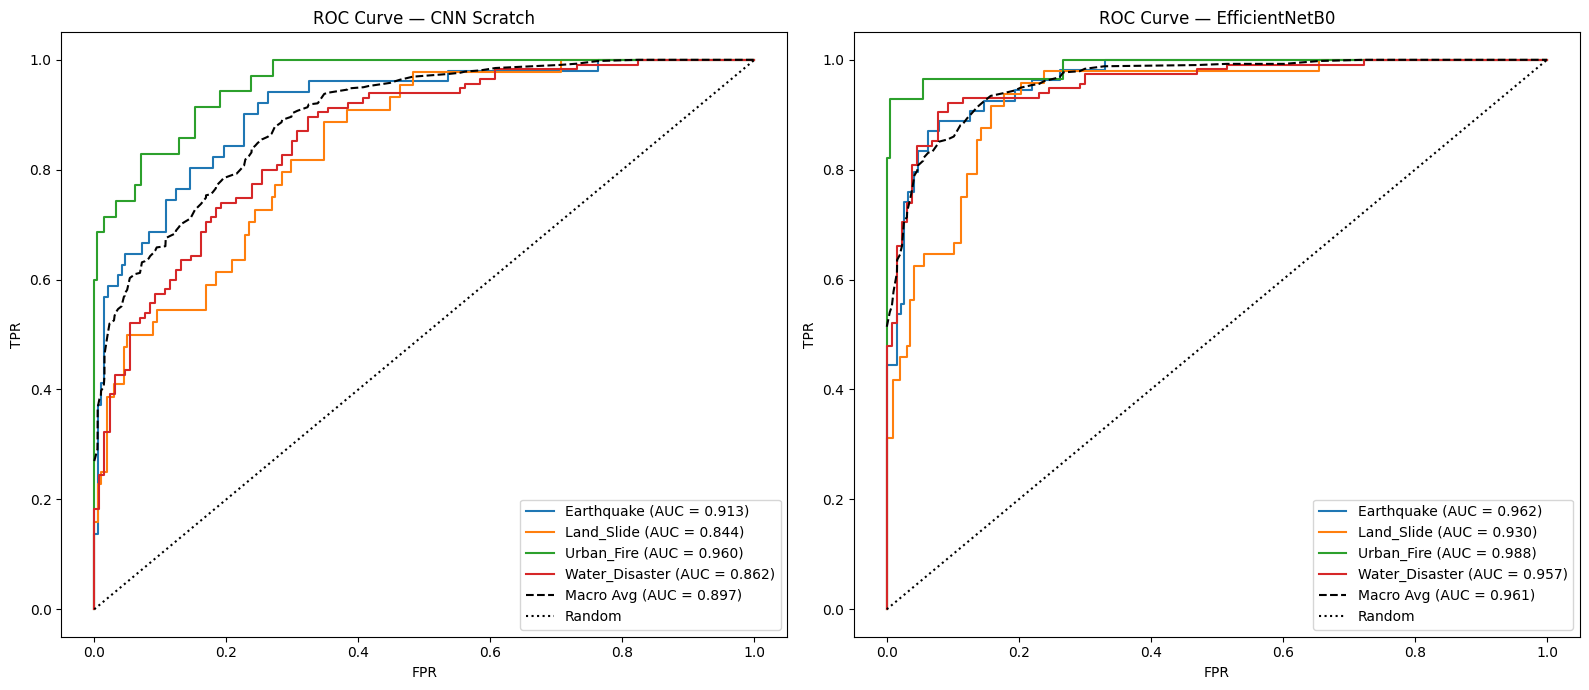

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = len(CLASS_NAMES)
y_true_bin_scratch = label_binarize(y_true_all,    classes=range(n_classes))
y_true_bin_effnet  = label_binarize(y_true_effnet, classes=range(n_classes))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, y_true_bin, y_prob, judul in zip(axes,
    [y_true_bin_scratch, y_true_bin_effnet],
    [y_prob_scratch, y_prob_effnet],
    ['CNN Scratch', 'EfficientNetB0']):

    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, label=f'{cls} (AUC = {auc(fpr, tpr):.3f})')

    all_fpr = np.unique(np.concatenate([roc_curve(y_true_bin[:, i], y_prob[:, i])[0] for i in range(n_classes)]))
    mean_tpr = np.mean([np.interp(all_fpr, roc_curve(y_true_bin[:, i], y_prob[:, i])[0],
                                           roc_curve(y_true_bin[:, i], y_prob[:, i])[1])
                        for i in range(n_classes)], axis=0)
    ax.plot(all_fpr, mean_tpr, 'k--', label=f'Macro Avg (AUC = {auc(all_fpr, mean_tpr):.3f})')
    ax.plot([0, 1], [0, 1], 'k:', label='Random')

    ax.set_title(f'ROC Curve — {judul}')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

**inshigt:**

Dari grafik ROC, dua kelas yang paling gampang dipisahin di kedua model adalah Urban_Fire dan Earthquake, kurva-nya paling jauh dari garis diagonal. Land_Slide paling susah, tapi EfficientNetB0 tetap jauh lebih baik

kila

In [ ]:
from sklearn.metrics import roc_auc_score

print(f"{'Kelas':<20} {'AUC Scratch':>12} {'AUC EfficientNet':>16}")
for i, cls in enumerate(CLASS_NAMES):
    auc_s = roc_auc_score(y_true_bin_scratch[:, i], y_prob_scratch[:, i])
    auc_e = roc_auc_score(y_true_bin_effnet[:, i],  y_prob_effnet[:, i])
    print(f"{cls:<20} {auc_s:>12.4f} {auc_e:>16.4f}")

macro_s = roc_auc_score(y_true_bin_scratch, y_prob_scratch, average='macro')
macro_e = roc_auc_score(y_true_bin_effnet,  y_prob_effnet,  average='macro')
ovo_s   = roc_auc_score(y_true_all,    y_prob_scratch, multi_class='ovo', average='macro')
ovo_e   = roc_auc_score(y_true_effnet, y_prob_effnet,  multi_class='ovo', average='macro')

print(f"{'Macro Average':<20} {macro_s:>12.4f} {macro_e:>16.4f}")
print(f"{'OvO Macro':<20} {ovo_s:>12.4f} {ovo_e:>16.4f}")

Kelas                 AUC Scratch AUC EfficientNet
Earthquake                 0.9131           0.9620
Land_Slide                 0.8441           0.9297
Urban_Fire                 0.9600           0.9880
Water_Disaster             0.8621           0.9572
Macro Average              0.8948           0.9592
OvO Macro                  0.8993           0.9610


**inshigt:**

Tabel ini mastiin apa yang keliatan di grafik: EfficientNetB0 unggul di semua kelas. Peningkatan terbesar ada di Land_Slide (+0.086) dan Water_Disaster (+0.095),  dua kelas yang paling susah dibedain secara visual. Macro AUC naik dari 0.8948 ke 0.9592